In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Diabetes prediction - EDA

In [66]:
data = pd.read_csv("../data/processed/diabetes_prediction_dataset.csv")

In [67]:
data

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0


Let's begin by checking for duplicates. With 100,000 records but only nine features, some of which are low-cardinality (e.g. rounded age, bmi, or glucose values), duplicate rows are likely to occur simply by chance. If a duplicate row ends up split across the train and test sets, the model would effectively be evaluated on data it has already seen during training - a form of data leakage that inflates performance metrics.

In [68]:
def find_duplicates(df, subset=None):
    dup_mask = df.duplicated(subset=subset, keep=False)
    group_cols = subset or list(df.columns)
    duplicate_rows = df[dup_mask].sort_values(by=group_cols)

    n_duplicate_rows = df.duplicated(subset=subset, keep="first").sum()
    n_groups = duplicate_rows.groupby(group_cols).ngroups if not duplicate_rows.empty else 0

    summary = {
        "rows_involved_in_duplication": len(duplicate_rows),
        "duplicate_rows_to_remove": n_duplicate_rows,
        "percent_duplicated": round(n_duplicate_rows / len(df) * 100, 2),
        "unique_duplicate_groups": n_groups
    }

    print(f"Rows involved in duplication: {summary['rows_involved_in_duplication']}")
    print(f"Duplicate rows to remove: {summary['duplicate_rows_to_remove']} "f"({summary['percent_duplicated']}%)")
    print(f"Unique duplicate groups: {summary['unique_duplicate_groups']}")

    return duplicate_rows, summary, group_cols

In [69]:
duplicate_rows, summary, group_cols = find_duplicates(data)
group_sizes = duplicate_rows.groupby(group_cols).size()

print(group_sizes.value_counts().sort_index())

Rows involved in duplication: 6939
Duplicate rows to remove: 3854 (3.85%)
Unique duplicate groups: 3085
2    2523
3     431
4      85
5      29
6       9
7       5
8       1
9       2
Name: count, dtype: int64


In [70]:
def remove_duplicates(df):
    rows_before = len(df)
    df_clean = df.drop_duplicates(keep="first").reset_index(drop=True)
    rows_after = len(df_clean)

    print(f"Rows before: {rows_before}")
    print(f"Rows after: {rows_after}")
    print(f"Removed: {rows_before - rows_after}")

    return df_clean

In [71]:
data = remove_duplicates(data)

Rows before: 100000
Rows after: 96146
Removed: 3854


We also check for duplicates while excluding the `diabetes` column. This identifies rows that share the exact same feature values but have a different target label - a case that a plain duplicate check (including the target) would miss entirely, since the rows themselves are not fully identical.

In [64]:
subset_cols = [c for c in data.columns if c != 'diabetes']
duplicate_rows, summary, group_cols = find_duplicates(data, subset=subset_cols)

Rows involved in duplication: 182
Duplicate rows to remove: 91 (0.09%)
Unique duplicate groups: 91


We found 91 groups of rows (182 rows total, ~0.09% of the dataset) that share identical feature values but disagree on the `diabetes` label. Unlike the full duplicates removed earlier, these are not treated as redundant data and are kept in the dataset.

This overlap is expected: several of the underlying features (e.g. rounded age, bmi, and glucose values) are low-cardinality, so distinct individuals can plausibly share the same recorded values while genuinely differing in diagnosis. Removing or arbitrarily relabeling these rows would not resolve the underlying ambiguity - it would only hide it. This is noted here as a limitation of the dataset's feature resolution.

Now, let's take a look at the `gender` and `age` columns.

In [89]:
def plot_categorical_distribution(df, column, by_target=None):
    """
    Plots the distribution of a categorical column as a count bar chart. If by_target is provided, bars are split by that target variable instead of showing percentage labels.
    """
    fig, ax = plt.subplots(figsize=(6, 4))

    if by_target:
        sns.countplot(x=column, hue=by_target, data=df, ax=ax)
        ax.set_title(f"{column} Distribution by {by_target}")
    else:
        counts = df[column].value_counts()
        percentages = df[column].value_counts(normalize=True) * 100
        sns.countplot(x=column, data=df, order=counts.index, ax=ax)

        ax.set_ylim(0, counts.max() * 1.15)

        for i, (count, pct) in enumerate(zip(counts, percentages)):
            ax.text(i, count, f"{count}\n({pct:.2f}%)", ha="center", va="bottom")
        ax.set_title(f"{column} Distribution")

    ax.set_xlabel(column)
    ax.set_ylabel("Count")
    plt.tight_layout()
    plt.show()

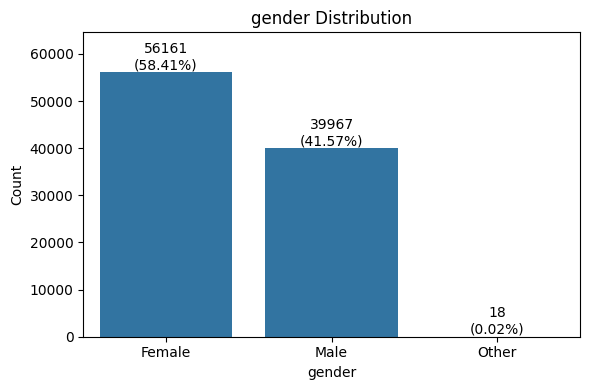

In [90]:
plot_categorical_distribution(data, "gender")

The dataset contains three categories: `female` (56,161), `male` (39,967), and `other` (18). The `other` category represents only 0.02% of the data - far too few observations to support any statistically meaningful analysis or for a model to learn a reliable pattern from. Keeping it would effectively be noise rather than signal, and one-hot encoding it would add a column that is almost entirely zeros. For these reasons, the 18 `other` rows are dropped from the dataset.

The remaining two categories are also not evenly distributed: females make up about 58% of the dataset and males about 42%. This imbalance is worth keeping in mind during modeling, though it is far less severe than the target variable's imbalance and does not require a separate correction on its own - it is simply noted here as part of understanding the data.

In [93]:
data = data[data["gender"] != "Other"].reset_index(drop=True)

In [94]:
print(data["gender"].unique())

['Female' 'Male']
